In [28]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

In [29]:
print("GPU:", tf.config.list_physical_devices('GPU'))

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [30]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 64

DATASET_PATH = "/kaggle/input/datasets/aaryapatel01/deepfake-images"

In [31]:
train_ds_full = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

val_ds_full = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 140002 files belonging to 2 classes.
Using 112002 files for training.
Found 140002 files belonging to 2 classes.
Using 28000 files for validation.


In [32]:
train_ds = train_ds_full
val_ds = val_ds_full

In [33]:
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.15),
])

In [34]:
from tensorflow.keras.applications.efficientnet import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(
    lambda x, y: (augment(x, training=True), y),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [35]:
def preprocess(image, label, training=False):
    image = tf.cast(image, tf.float32)

    if training:
        image = augment(image, training=True)

    image = preprocess_input(image)
    return image, label


train_ds = train_ds.map(lambda x, y: preprocess(x, y, True))
val_ds = val_ds.map(lambda x, y: preprocess(x, y, False))

In [36]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224,224,3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation='sigmoid', dtype='float32')(x)

model = Model(inputs, outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [37]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

In [38]:
checkpoint= ModelCheckpoint(
    "/kaggle/working/deepfake_last.keras",
    monitor="val_loss",
    save_best_only=False,
    save_weights_only=False,
    save_freq="epoch"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2
)

In [39]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/5


I0000 00:00:1782619563.820871     137 service.cc:152] XLA service 0x7e02b8014560 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782619563.820923     137 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782619563.820927     137 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782619567.787049     137 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782619600.025613     137 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1751/1751 ━━━━━━━━━━━━━━━━━━━━ 2182s 1s/step - accuracy: 0.7141 - auc: 0.7917 - loss: 0.5475 - val_accuracy: 0.7437 - val_auc: 0.8622 - val_loss: 0.5082 - learning_rate: 1.0000e-04
Epoch 2/5
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 1980s 1s/step - accuracy: 0.7598 - auc: 0.8412 - loss: 0.4888 - val_accuracy: 0.7470 - val_auc: 0.8738 - val_loss: 0.5038 - learning_rate: 1.0000e-04
Epoch 3/5
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 2003s 1s/step - accuracy: 0.7729 - auc: 0.8545 - loss: 0.4703 - val_accuracy: 0.7513 - val_auc: 0.8799 - val_loss: 0.4974 - learning_rate: 1.0000e-04
Epoch 4/5
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 2000s 1s/step - accuracy: 0.7783 - auc: 0.8623 - loss: 0.4585 - val_accuracy: 0.7604 - val_auc: 0.8825 - val_loss: 0.4850 - learning_rate: 1.0000e-04
Epoch 5/5
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 1982s 1s/step - accuracy: 0.7819 - auc: 0.8656 - loss: 0.4535 - val_accuracy: 0.7563 - val_auc: 0.8848 - val_loss: 0.4918 - learning_rate: 1.0000e-04


In [40]:
base_model.trainable = True

# Freeze most layers, train only last part
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [41]:

   model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [42]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/5


2026-06-28 06:55:24.739160: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 06:55:24.898110: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 06:55:25.044037: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 06:55:25.232623: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 06:55:25.409618: E external/local_xla/xla/stream_

1750/1751 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7431 - auc: 0.8241 - loss: 0.5125 - precision: 0.7463 - recall: 0.7347

2026-06-28 07:28:42.362908: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 07:28:42.523870: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 07:28:42.698569: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-28 07:28:42.868399: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1751/1751 ━━━━━━━━━━━━━━━━━━━━ 2107s 1s/step - accuracy: 0.7760 - auc: 0.8606 - loss: 0.4627 - precision: 0.7715 - recall: 0.7837 - val_accuracy: 0.8210 - val_auc: 0.9287 - val_loss: 0.3918 - val_precision: 0.9092 - val_recall: 0.7148 - learning_rate: 1.0000e-05
Epoch 2/5
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 1982s 1s/step - accuracy: 0.8347 - auc: 0.9163 - loss: 0.3660 - precision: 0.8253 - recall: 0.8487 - val_accuracy: 0.8440 - val_auc: 0.9475 - val_loss: 0.3574 - val_precision: 0.9320 - val_recall: 0.7433 - learning_rate: 1.0000e-05
Epoch 3/5
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 1979s 1s/step - accuracy: 0.8553 - auc: 0.9336 - loss: 0.3274 - precision: 0.8470 - recall: 0.8670 - val_accuracy: 0.8539 - val_auc: 0.9564 - val_loss: 0.3394 - val_precision: 0.9414 - val_recall: 0.7559 - learning_rate: 1.0000e-05
Epoch 4/5
1751/1751 ━━━━━━━━━━━━━━━━━━━━ 1968s 1s/step - accuracy: 0.8679 - auc: 0.9437 - loss: 0.3022 - precision: 0.8606 - recall: 0.8776 - val_accuracy: 0.8612 - val_auc: 0.9622 - val_loss

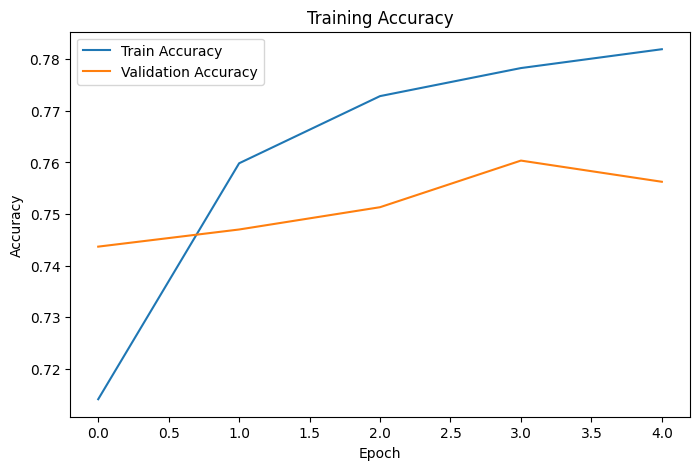

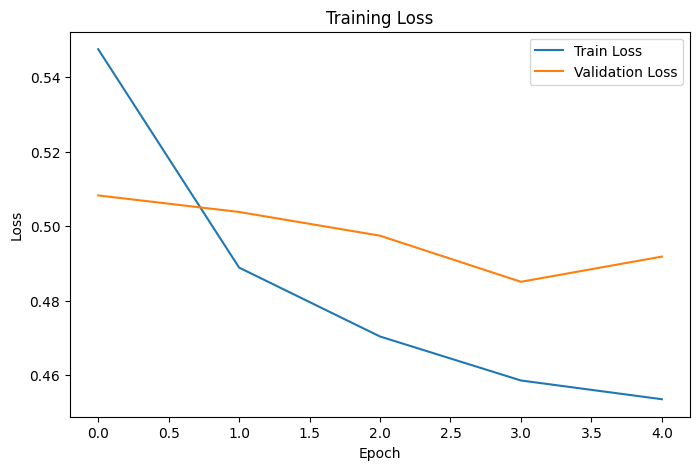

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [44]:
results = model.evaluate(val_ds)

print("Loss:", results[0])
print("Accuracy:", results[1])
print("AUC:", results[2])

438/438 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.8612 - auc: 0.9622 - loss: 0.3284 - precision: 0.9492 - recall: 0.7643
Loss: 0.32835936546325684
Accuracy: 0.8611785769462585
AUC: 0.9491779804229736


In [45]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())

In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

              precision    recall  f1-score   support

        Real       0.80      0.96      0.87     13949
        Fake       0.95      0.76      0.85     14051

    accuracy                           0.86     28000
   macro avg       0.88      0.86      0.86     28000
weighted avg       0.88      0.86      0.86     28000



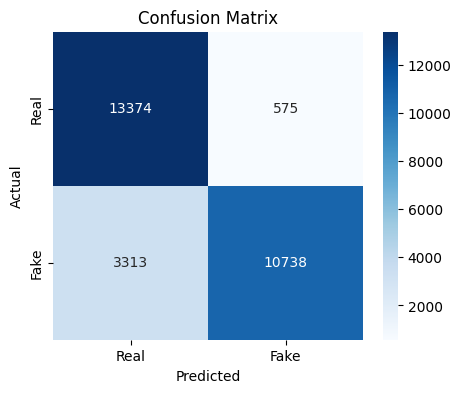

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Real","Fake"],
            yticklabels=["Real","Fake"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

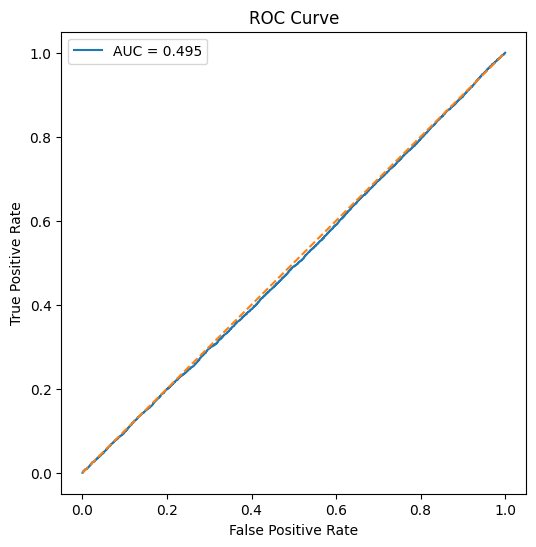

In [48]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_scores = []

for images, _ in val_ds:
    preds = model.predict(images, verbose=0)
    y_scores.extend(preds.flatten())

fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [49]:
model.save("/kaggle/working/deepfake_final.keras")

In [50]:
import tensorflow as tf

model = tf.keras.models.load_model("/kaggle/working/deepfake_final.keras")
print("Model loaded successfully")

Model loaded successfully


In [51]:
import numpy as np
from tensorflow.keras.applications.efficientnet import preprocess_input
import tensorflow as tf

IMG_SIZE = (224, 224)

def predict_image(img):
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    img = tf.expand_dims(img, axis=0)

    pred = model.predict(img, verbose=0)[0][0]

    if pred > 0.5:
        return f"FAKE ❌ ({pred:.2f})"
    else:
        return f"REAL ✅ ({1-pred:.2f})"

In [52]:
!pip install gradio -q

In [53]:
import gradio as gr
import tensorflow as tf
import numpy as np
from tensorflow.keras.applications.efficientnet import preprocess_input

In [54]:
model = tf.keras.models.load_model("/kaggle/working/deepfake_final.keras")

In [55]:
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = (224, 224)

def predict(image):

    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)
    image = tf.expand_dims(image, 0)

    pred = model.predict(image, verbose=0)[0][0]

    fake_prob = float(pred)
    real_prob = 1 - fake_prob

    if fake_prob >= 0.5:
        prediction = "❌ FAKE"
        confidence = fake_prob
    else:
        prediction = "✅ REAL"
        confidence = real_prob

    return (
        prediction,
        f"{confidence*100:.2f} %",
        f"{real_prob*100:.2f} %",
        f"{fake_prob*100:.2f} %"
    )

In [56]:
import gradio as gr

demo = gr.Interface(
    fn=predict,

    inputs=gr.Image(type="numpy", label="Upload Face Image"),

    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Textbox(label="Confidence"),
        gr.Textbox(label="Real Probability"),
        gr.Textbox(label="Fake Probability"),
    ],

    title="🕵️ AI Deepfake Detection System",

    description="""
Upload an image to determine whether it is **Real** or **AI Generated (Deepfake)**.

Model: EfficientNetB0 + Transfer Learning
""",

    theme=gr.themes.Soft()
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://cc0f9df0b793f5608d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
